# Echo State Network — Per-Motor Current Prediction (Power Limiter)

| Property | Value |
|----------|-------|
| **Model** | Echo State Network (Reservoir Computing) |
| **Input** | [I_FL, I_FR, I_RL, I_RR, T_sum, U_dc] normalized |
| **Output** | I_FL, I_FR, I_RL, I_RR at t+1 (multi-output Ridge readout) |
| **Training** | Ridge regression on reservoir states — no backprop |

**Why ESN:** no manual lag engineering — reservoir handles multi-scale temporal memory.
Training = one Ridge regression (< 2 s for N=300 neurons).

In [1]:
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path().resolve()
SRC_DIR  = _cwd if (_cwd / 'functions').exists() else _cwd / 'src'
DATA_DIR = SRC_DIR.parent / 'data' / 'model'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DT            = 0.2        # 5 Hz sample rate
N_LAGS        = 5          # 1 s lookback (5 ticks × 0.2 s)
POWER_LIMIT_W = 80_000
MOTOR_NAMES   = ['FL', 'FR', 'RL', 'RR']
from functions.esn        import EchoStateNetwork
from functions.evaluation import display_model_results, compare_models

WASHOUT = 50   # reservoir settling steps per run
print(f'DATA_DIR : {DATA_DIR}')


DATA_DIR : /home/michal/Desktop/PUTMotorsport/PowerLimiter/PUTM_EV_FF_CurrentLoop/data/model


## 1. Data Loading

In [2]:
df = pd.read_csv(DATA_DIR / 'training_data.csv')
df = df.sort_values(['run_id', 'timestamp_s']).reset_index(drop=True)
df['T_sum'] = df['T_FL'] + df['T_FR'] + df['T_RL'] + df['T_RR']

# Run-safe lag features (no cross-run leakage)
for m in MOTOR_NAMES:
    for lag in range(1, N_LAGS + 1):
        df[f'I_{m}_lag{lag}'] = df.groupby('run_id')[f'I_{m}'].shift(lag)
for lag in range(1, N_LAGS + 1):
    df[f'T_sum_lag{lag}'] = df.groupby('run_id')['T_sum'].shift(lag)

# 1-step-ahead target (within each run)
for m in MOTOR_NAMES:
    df[f'I_{m}_next'] = df.groupby('run_id')[f'I_{m}'].shift(-1)

df_clean = df.dropna().reset_index(drop=True)
print(f'Loaded  : {len(df):,} rows, {df["run_id"].nunique()} runs')
print(f'Clean   : {len(df_clean):,} rows after dropna')


Loaded  : 5,693 rows, 10 runs
Clean   : 5,633 rows after dropna


In [3]:
runs         = sorted(df_clean['run_id'].unique())
n_train_runs = max(1, int(len(runs) * 0.70))
train_runs   = runs[:n_train_runs]
test_runs    = runs[n_train_runs:]

df_train = df_clean[df_clean['run_id'].isin(train_runs)].reset_index(drop=True)
df_test  = df_clean[df_clean['run_id'].isin(test_runs)].reset_index(drop=True)

y_train = df_train[[f'I_{m}_next' for m in MOTOR_NAMES]].values   # (n, 4)
y_test  = df_test[[f'I_{m}_next'  for m in MOTOR_NAMES]].values
U_test  = df_test['U_dc'].values
t_test  = df_test['timestamp_s'].values

print(f'Train runs : {train_runs}  ({len(df_train):,} samples)')
print(f'Test  runs : {test_runs}   ({len(df_test):,} samples)')
print(f'y_train    : {y_train.shape}')


Train runs : [2, 3, 4, 5, 6, 7, 8]  (3,730 samples)
Test  runs : [9, 10, 11]   (1,903 samples)
y_train    : (3730, 4)


## 2. ESN Input Matrix

6 channels: [I_FL, I_FR, I_RL, I_RR, T_sum, U_dc] — normalized.

In [4]:
ch_cols  = ['I_FL', 'I_FR', 'I_RL', 'I_RR', 'T_sum', 'U_dc']
U_raw    = df_train[ch_cols].values   # (n_train, 6)
U_test_m = df_test[ch_cols].values    # (n_test, 6)

mu    = U_raw.mean(axis=0)
sigma = U_raw.std(axis=0) + 1e-8
U_norm_train = (U_raw     - mu) / sigma
U_norm_test  = (U_test_m  - mu) / sigma

print(f'Channels : {ch_cols}')
print(f'mu       : {mu.round(1)}')
print(f'sigma    : {sigma.round(1)}')


Channels : ['I_FL', 'I_FR', 'I_RL', 'I_RR', 'T_sum', 'U_dc']
mu       : [2403.6 3143.5 4821.4 4234.3  523.4  555.6]
sigma    : [4119.6 5947.2 9477.2 8299.9  982.3   10.5]


## 3. Training

In [5]:
esn = EchoStateNetwork(
    n_inputs        = 6,
    n_reservoir     = 300,
    spectral_radius = 0.95,
    leaking_rate    = 0.3,
    sparsity        = 0.90,
    ridge_alpha     = 1e-4,
    seed            = 42,
)

t0 = time.perf_counter()
esn.fit(U_norm_train, y_train, washout=WASHOUT)
t_train = time.perf_counter() - t0

print(f'Train time : {t_train*1000:.1f} ms')
print(f'Reservoir  : {esn.N} neurons  (rho={esn.rho}, alpha={esn.alpha})')
print(f'Readout    : {esn._ridge.coef_.shape}  (n_outputs x n_reservoir)')


Train time : 137.6 ms
Reservoir  : 300 neurons  (rho=0.95, alpha=0.3)
Readout    : (4, 300)  (n_outputs x n_reservoir)


## 4. Evaluation

Inference : 84.75 ms  (1903 samples)
y_pred shape : (1903, 4)
  MODEL: ESN 4-motor
  R2              : 0.2214
  RMSE            : 7818.18 A
  MAE             : 5108.75 A
  MedAE           : 3260.62 A
  MAPE            : 323.44 %
  R2 per motor    : FL=0.118  FR=0.131  RL=0.287  RR=0.168
--------------------------------------------------------
  Under-pred.     : 54.8 % of samples
  Mean under-pred.: 5007.00 A   (dangerous direction!)
--------------------------------------------------------
  Power RMSE      : 15260.90 kW
  Real violations : 1903 events > 80 kW
  Missed (FN)     : 675   <- CRITICAL
  Unnecessary (FP): 0
  Violation recall: 64.5 %
--------------------------------------------------------
  Time/sample     : 0.0445 ms
  Frequency       : 22454.8 Hz

  [Excel] Result added → /home/michal/Desktop/PUTMotorsport/PowerLimiter/PUTM_EV_FF_CurrentLoop/src/model_results.xlsx



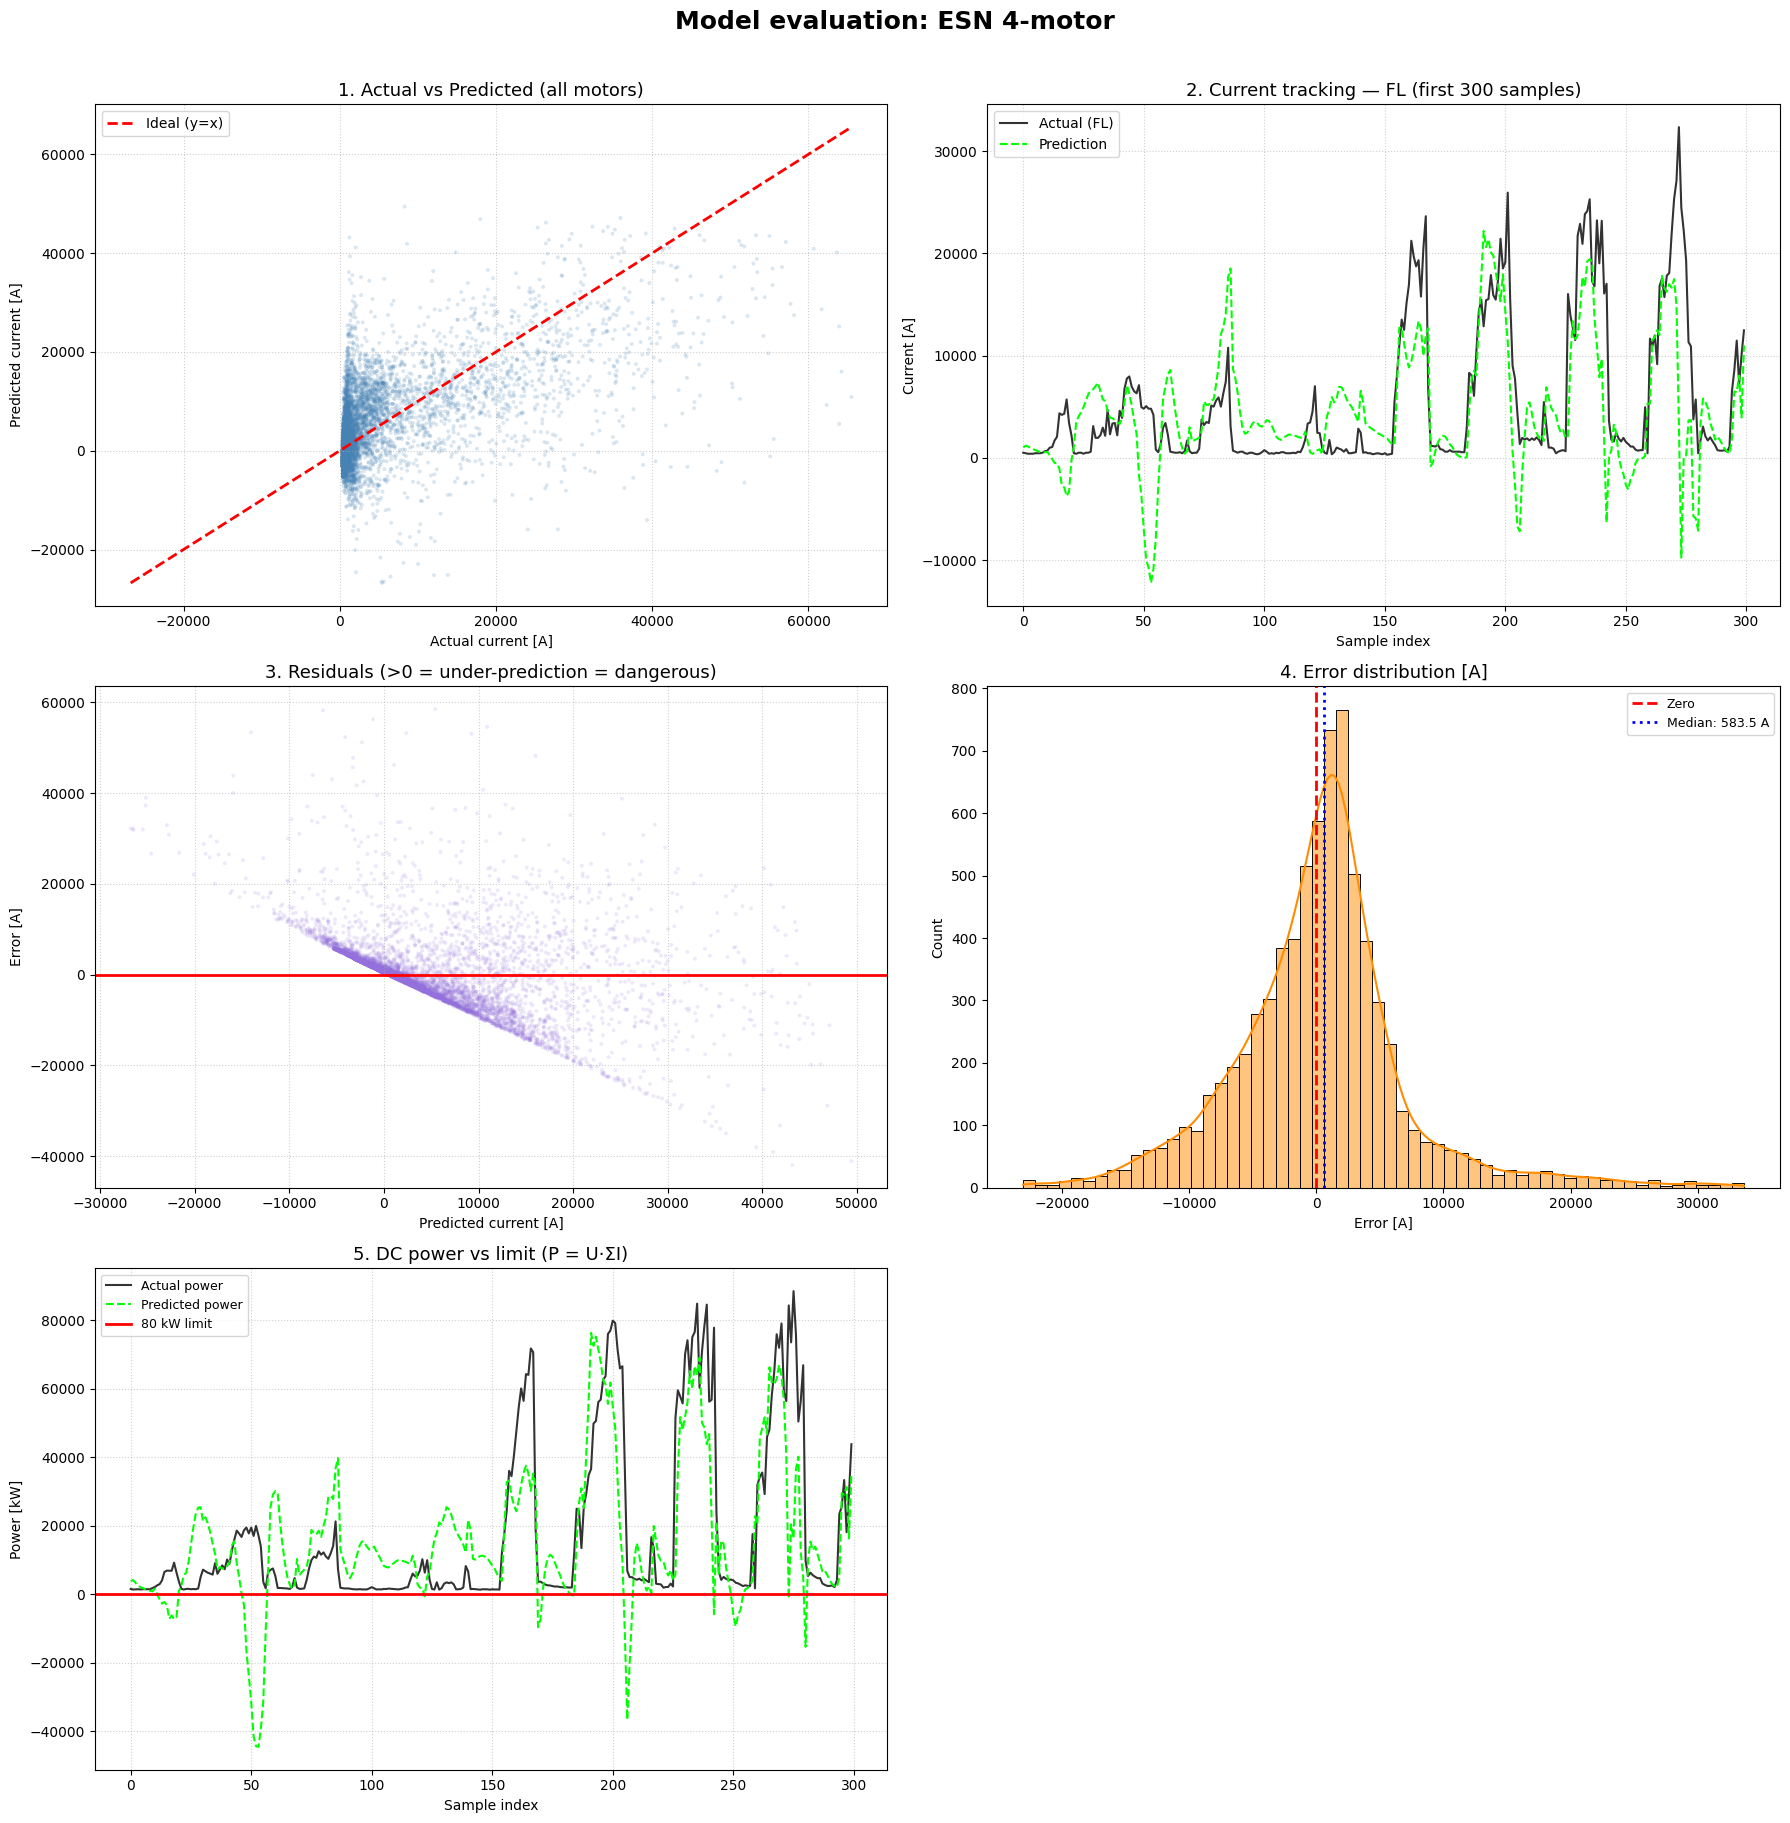

In [6]:
t0 = time.perf_counter()
y_pred_esn = esn.predict(U_norm_test, warm_start=True)
t_infer = time.perf_counter() - t0

print(f'Inference : {t_infer*1000:.2f} ms  ({len(U_norm_test)} samples)')
print(f'y_pred shape : {y_pred_esn.shape}')

metrics = display_model_results(
    'ESN 4-motor', y_test, y_pred_esn, t_infer,
    voltage=U_test, motor_names=MOTOR_NAMES, save_to_excel=True,
)


## 5. Time-Series Preview

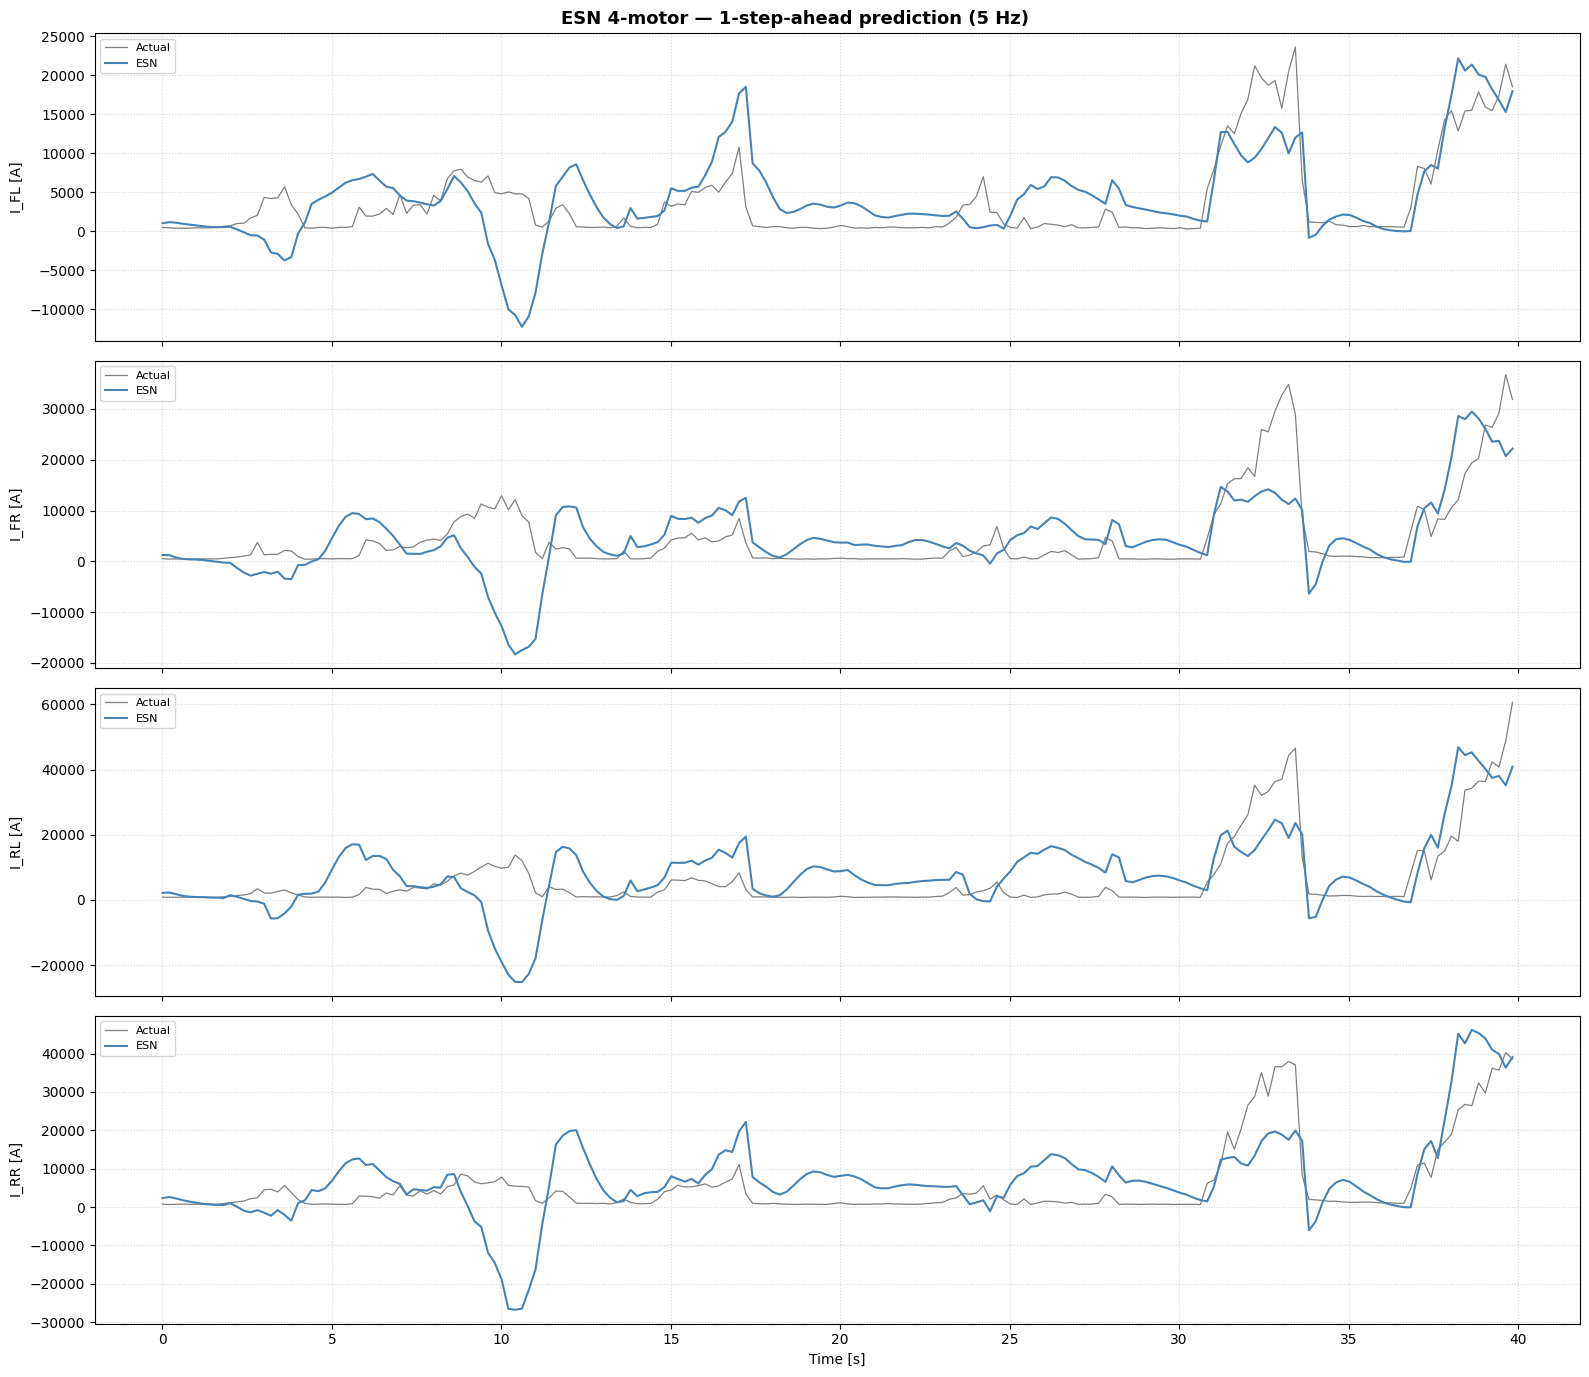

In [7]:
N_PLOT = min(200, len(y_test))
sl     = slice(0, N_PLOT)
t_pl   = t_test[sl] - t_test[0]

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle('ESN 4-motor — 1-step-ahead prediction (5 Hz)', fontsize=13, fontweight='bold')
for i, (ax, m) in enumerate(zip(axes, MOTOR_NAMES)):
    ax.plot(t_pl, y_test[sl, i],     lw=0.9, color='black',     alpha=0.5, label='Actual')
    ax.plot(t_pl, y_pred_esn[sl, i], lw=1.5, color='steelblue',            label='ESN')
    ax.set_ylabel(f'I_{m} [A]'); ax.legend(fontsize=8); ax.grid(True, ls=':', alpha=0.5)
axes[-1].set_xlabel('Time [s]')
plt.tight_layout(); plt.show()


## 6. Hyperparameter Sweep

Sweep spectral_radius x leaking_rate — two most impactful ESN parameters.

  rho=0.50  alpha=0.1  RMSE=11514.48 A
  rho=0.50  alpha=0.3  RMSE=7384.14 A
  rho=0.50  alpha=0.5  RMSE=7069.03 A
  rho=0.50  alpha=0.8  RMSE=6441.75 A
  rho=0.70  alpha=0.1  RMSE=13680.39 A
  rho=0.70  alpha=0.3  RMSE=6946.87 A
  rho=0.70  alpha=0.5  RMSE=6427.45 A
  rho=0.70  alpha=0.8  RMSE=6154.10 A
  rho=0.90  alpha=0.1  RMSE=14072.82 A
  rho=0.90  alpha=0.3  RMSE=6832.66 A
  rho=0.90  alpha=0.5  RMSE=6281.07 A
  rho=0.90  alpha=0.8  RMSE=6075.60 A
  rho=0.95  alpha=0.1  RMSE=14377.37 A
  rho=0.95  alpha=0.3  RMSE=6803.78 A
  rho=0.95  alpha=0.5  RMSE=6301.29 A
  rho=0.95  alpha=0.8  RMSE=6079.79 A
  rho=0.99  alpha=0.1  RMSE=14784.87 A
  rho=0.99  alpha=0.3  RMSE=6751.54 A
  rho=0.99  alpha=0.5  RMSE=6306.36 A
  rho=0.99  alpha=0.8  RMSE=6081.83 A


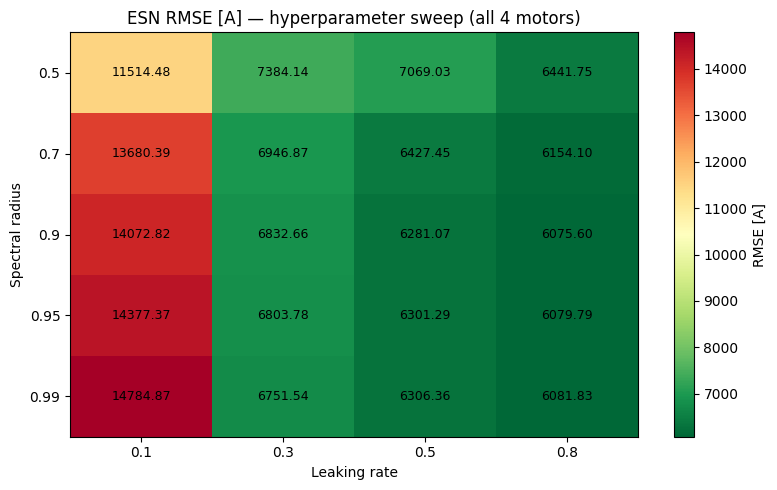

Best: rho=0.9, alpha=0.8  -> RMSE=6075.60 A


In [8]:
rho_vals   = [0.5, 0.7, 0.9, 0.95, 0.99]
alpha_vals = [0.1, 0.3, 0.5, 0.8]

rmse_grid = np.zeros((len(rho_vals), len(alpha_vals)))
for i, rho in enumerate(rho_vals):
    for j, alpha in enumerate(alpha_vals):
        _esn = EchoStateNetwork(n_inputs=6, n_reservoir=200,
                                spectral_radius=rho, leaking_rate=alpha,
                                ridge_alpha=1e-4, seed=42)
        _esn.fit(U_norm_train, y_train, washout=WASHOUT)
        yh = _esn.predict(U_norm_test, warm_start=True)
        rmse_grid[i, j] = np.sqrt(np.mean((y_test - yh)**2))
        print(f'  rho={rho:.2f}  alpha={alpha:.1f}  RMSE={rmse_grid[i,j]:.2f} A')

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(rmse_grid, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(alpha_vals))); ax.set_xticklabels(alpha_vals)
ax.set_yticks(range(len(rho_vals)));   ax.set_yticklabels(rho_vals)
ax.set_xlabel('Leaking rate'); ax.set_ylabel('Spectral radius')
ax.set_title('ESN RMSE [A] — hyperparameter sweep (all 4 motors)')
plt.colorbar(im, ax=ax, label='RMSE [A]')
for ii in range(len(rho_vals)):
    for jj in range(len(alpha_vals)):
        ax.text(jj, ii, f'{rmse_grid[ii,jj]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout(); plt.show()

best_i, best_j = np.unravel_index(np.argmin(rmse_grid), rmse_grid.shape)
print(f'Best: rho={rho_vals[best_i]}, alpha={alpha_vals[best_j]}  -> RMSE={rmse_grid[best_i, best_j]:.2f} A')


## 7. Best Configuration

  MODEL: ESN best (rho=0.9, alpha=0.8)
  R2              : 0.4326
  RMSE            : 6674.50 A
  MAE             : 3414.53 A
  MedAE           : 1231.99 A
  MAPE            : 160.22 %
  R2 per motor    : FL=0.474  FR=0.459  RL=0.367  RR=0.469
--------------------------------------------------------
  Under-pred.     : 66.9 % of samples
  Mean under-pred.: 3233.86 A   (dangerous direction!)
--------------------------------------------------------
  Power RMSE      : 12937.48 kW
  Real violations : 1903 events > 80 kW
  Missed (FN)     : 654   <- CRITICAL
  Unnecessary (FP): 0
  Violation recall: 65.6 %
--------------------------------------------------------
  Time/sample     : 0.0553 ms
  Frequency       : 18088.5 Hz



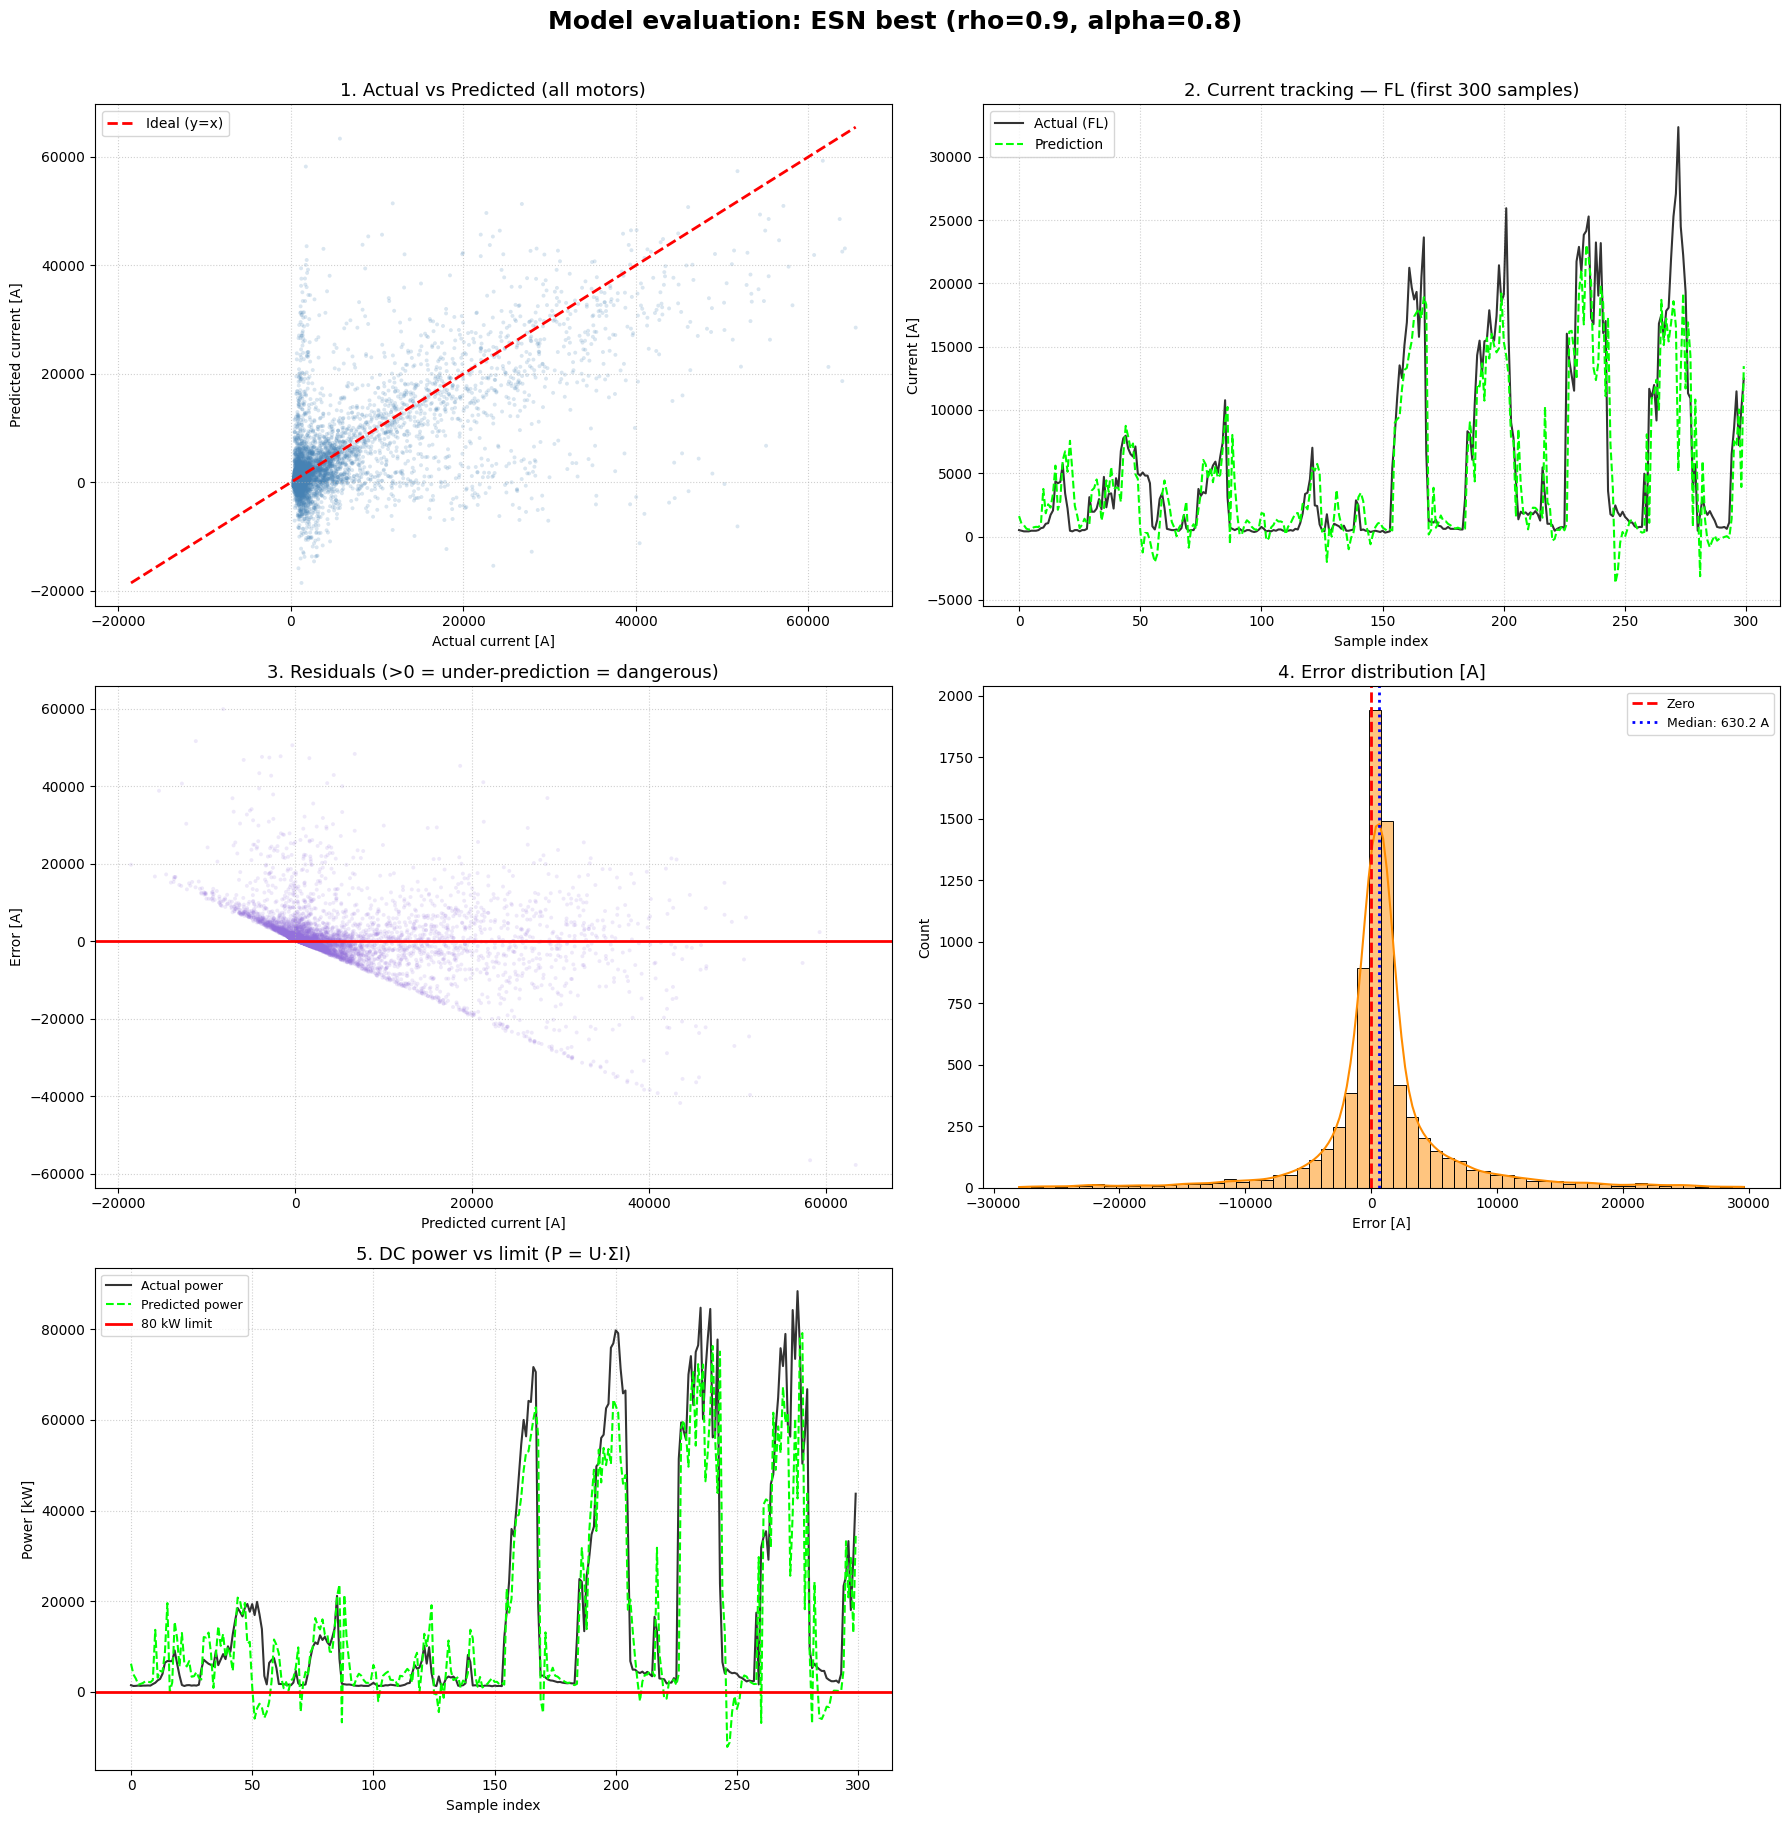


  MODEL COMPARISON
                                 R2  RMSE [A]  MAE [A]  MedAE [A]  MAPE [%]  Underpred. [%]  Mean underpred. [A]  ms/sample  Freq. [Hz]  R2_FL  R2_FR  R2_RL  R2_RR  Power RMSE [kW]  Violations [n]  FN (missed)  FP (unnecessary)  Violation recall [%]
model                                                                                                                                                                                                                                                    
ESN best (rho=0.9, alpha=0.8) 0.433  6674.503 3414.533   1231.988   160.220          66.881             3233.863      0.055   18088.502  0.474  0.459  0.367  0.469        12937.479            1903          654                 0                65.633
ESN 4-motor                   0.221  7818.179 5108.754   3260.624   323.439          54.808             5007.003      0.045   22454.850  0.118  0.131  0.287  0.168        15260.896            1903          675                 0   

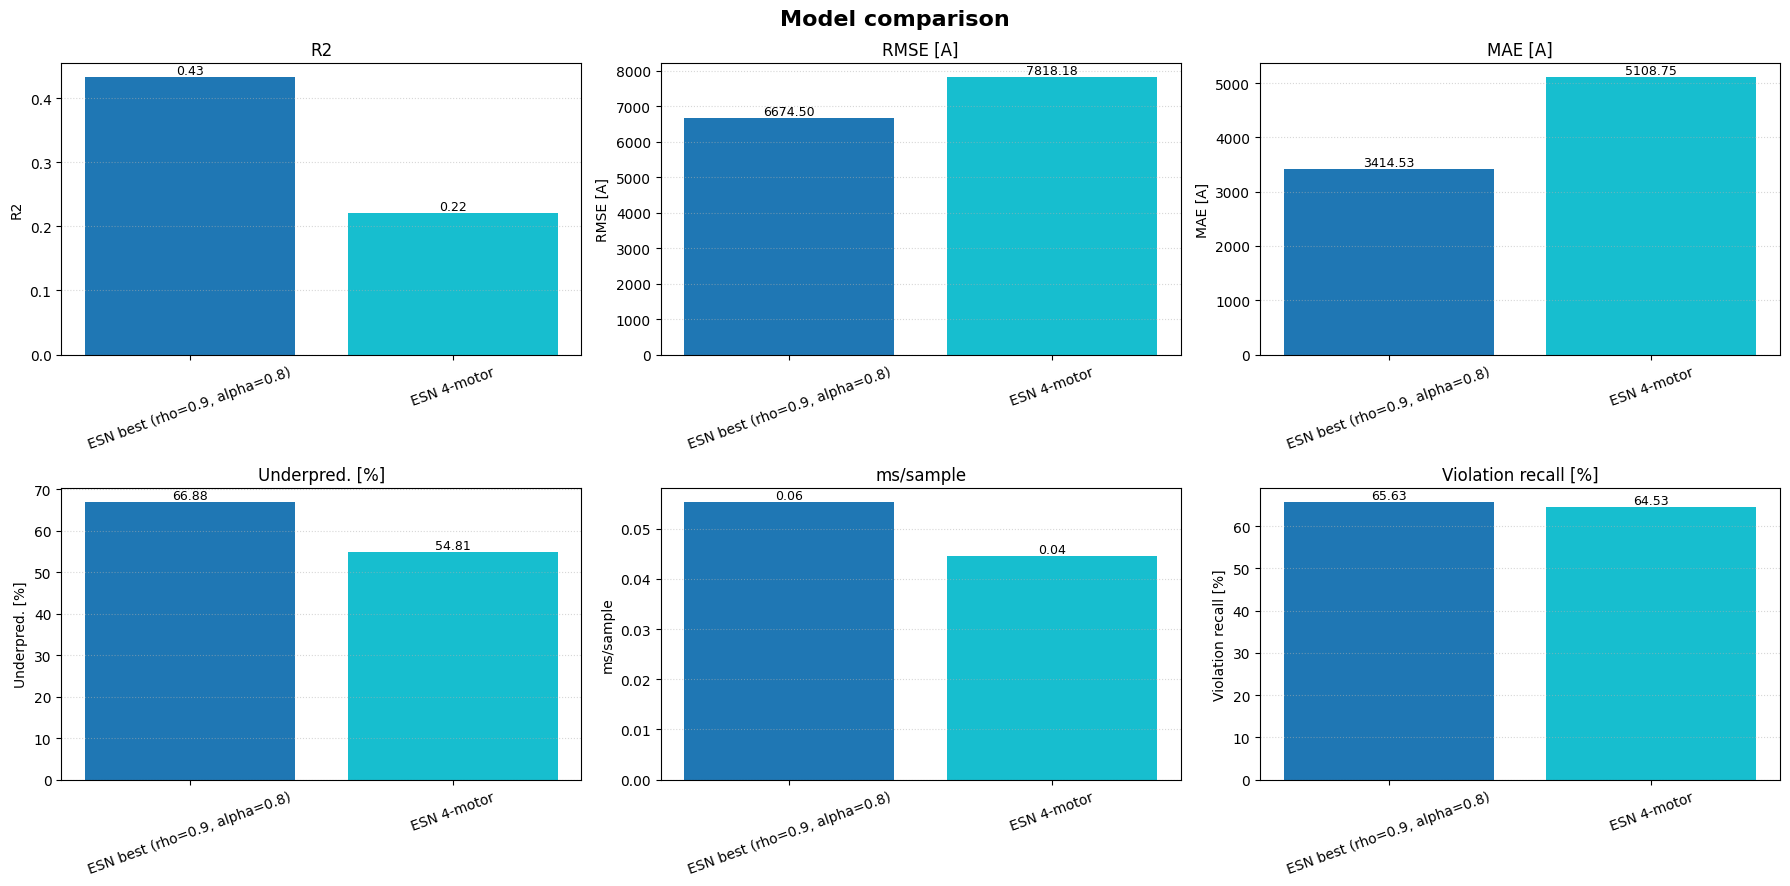

,R2,RMSE [A],MAE [A],MedAE [A],MAPE [%],Underpred. [%],Mean underpred. [A],ms/sample,Freq. [Hz],R2_FL,R2_FR,R2_RL,R2_RR,Power RMSE [kW],Violations [n],FN (missed),FP (unnecessary),Violation recall [%]
model,,,,,,,,,,,,,,,,,,
"ESN best (rho=0.9, alpha=0.8)",0.432559,6674.503009,3414.532937,1231.988174,160.219621,66.881240,3233.862786,0.055284,18088.501974,0.474334,0.459483,0.366835,0.469304,12937.478676,1903,654,0,65.633211
ESN 4-motor,0.221437,7818.179495,5108.754211,3260.624487,323.439163,54.808198,5007.002663,0.044534,22454.849587,0.118482,0.131153,0.286562,0.168458,15260.896278,1903,675,0,64.529690


In [9]:
esn_best = EchoStateNetwork(
    n_inputs=6, n_reservoir=300,
    spectral_radius=rho_vals[best_i], leaking_rate=alpha_vals[best_j],
    ridge_alpha=1e-4, seed=42,
)
t0 = time.perf_counter()
esn_best.fit(U_norm_train, y_train, washout=WASHOUT)
t_tb = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_best = esn_best.predict(U_norm_test, warm_start=True)
t_ib = time.perf_counter() - t0

m_best = display_model_results(
    f'ESN best (rho={rho_vals[best_i]}, alpha={alpha_vals[best_j]})',
    y_test, y_pred_best, t_ib,
    voltage=U_test, motor_names=MOTOR_NAMES, save_to_excel=False,
)
compare_models([metrics, m_best], sort_by='RMSE [A]')
